# GSE5090 Data Analysis
Microarray gene expression data from the GSE5090 dataset were obtained from the GEO Series Matrix and processed into a probe-by-sample expression matrix, with accompanying metadata used to classify samples as obese with PCOS or obese controls. Probe-level data were mapped to gene symbols using platform annotation and collapsed to gene-level expression to avoid redundancy.

Global transcriptional structure was first assessed using principal component analysis (PCA) and sample-to-sample correlation heatmaps, which revealed high overall similarity and no clear separation between groups. Differential expression analysis was then performed using Welch’s t-test, with log2 fold change and false discovery rate (FDR)-adjusted p-values computed; however, no genes passed multiple testing correction, indicating modest gene-level differences. To better capture transcriptional patterns, ranked gene lists were used for gene set enrichment analysis (GSEA), which identified coordinated pathway-level changes, including rends for enrichment of metabolic processes (e.g., adipogenesis and oxidative phosphorylation) and suppression of inflammatory signaling pathways. Transcription factor enrichment analysis further linked these changes to upstream regulators such as PPARG, CREB1, and HNF4A (upregulated) and RELA and SMAD family members (downregulated).

Unsupervised analyses, including heatmaps of top variable genes, revealed structured but heterogeneous gene expression patterns that did not clearly separate groups. To uncover latent structure, non-negative matrix factorization (NMF) was applied to identify co-expression modules representing coordinated gene programs. Three modules were identified, corresponding to inflammatory/stress-response, structural/extracellular matrix, and metabolic/oxidative processes. Comparison of module activity across groups revealed subtle trends—Modules 2 and 3 were slightly elevated and Module 1 slightly reduced in PCOS—though none reached statistical significance. Overall, the analysis demonstrates that obesity-independent PCOS effects in adipose tissue are characterized by subtle, coordinated shifts in gene programs rather than strong differential expression of individual genes.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import sys
import subprocess

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for pkg in ["GEOparse", "pandas", "numpy", "matplotlib", "seaborn", "scikit-learn", "scipy", "statsmodels"]:
    pip_install(pkg)

print("Packages installed.")

Mounted at /content/drive
Packages installed.


In [2]:
import os
import gzip
import urllib.request
from io import StringIO

import numpy as np
import pandas as pd
import GEOparse
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import ttest_ind, zscore
from statsmodels.stats.multitest import multipletests

WORKDIR = "/content/gse5090_series_pipeline"
OUTDIR = os.path.join(WORKDIR, "results")
PLOTDIR = os.path.join(OUTDIR, "plots")

for d in [WORKDIR, OUTDIR, PLOTDIR]:
    os.makedirs(d, exist_ok=True)

print("Working directory:", WORKDIR)

Working directory: /content/gse5090_series_pipeline


In [3]:
# Download the GEO series matrix and GPL96 platform annotation

matrix_url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE5nnn/GSE5090/matrix/GSE5090_series_matrix.txt.gz"
matrix_path = os.path.join(WORKDIR, "GSE5090_series_matrix.txt.gz")

if not os.path.exists(matrix_path):
    urllib.request.urlretrieve(matrix_url, matrix_path)

gpl = GEOparse.get_GEO("GPL96", destdir=WORKDIR, how="quick")

print("Downloaded GSE5090 series matrix and GPL96 platform annotation.")

11-May-2026 18:28:20 DEBUG utils - Directory /content/gse5090_series_pipeline already exists. Skipping.
DEBUG:GEOparse:Directory /content/gse5090_series_pipeline already exists. Skipping.
11-May-2026 18:28:20 INFO GEOparse - Downloading http://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?targ=self&acc=GPL96&form=text&view=quick to /content/gse5090_series_pipeline/GPL96.txt
INFO:GEOparse:Downloading http://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?targ=self&acc=GPL96&form=text&view=quick to /content/gse5090_series_pipeline/GPL96.txt
11-May-2026 18:28:21 DEBUG downloader - Total size: 0
DEBUG:GEOparse:Total size: 0
11-May-2026 18:28:21 DEBUG downloader - md5: None
DEBUG:GEOparse:md5: None
1.45MB [00:00, 4.39MB/s]
11-May-2026 18:28:21 DEBUG downloader - Moving /tmp/tmposerok5w to /content/gse5090_series_pipeline/GPL96.txt
DEBUG:GEOparse:Moving /tmp/tmposerok5w to /content/gse5090_series_pipeline/GPL96.txt
11-May-2026 18:28:21 DEBUG downloader - Successfully downloaded http://www.ncbi.nlm.nih.gov/g

Downloaded GSE5090 series matrix and GPL96 platform annotation.


In [4]:
# Parse the series matrix file directly

metadata = {}
table_lines = []
in_table = False

with gzip.open(matrix_path, "rt") as f:
    for line in f:
        line = line.rstrip("\n")

        if line.startswith("!series_matrix_table_begin"):
            in_table = True
            continue
        if line.startswith("!series_matrix_table_end"):
            in_table = False
            continue

        if in_table:
            table_lines.append(line + "\n")
        elif line.startswith("!Sample_"):
            parts = line.split("\t")
            key = parts[0].replace("!Sample_", "")
            values = [p.strip().strip('"') for p in parts[1:]]
            metadata[key] = values

expr_df = pd.read_csv(StringIO("".join(table_lines)), sep="\t")
expr_df = expr_df.rename(columns={"ID_REF": "probe_id"})
expr_df.columns = [str(c).strip().strip('"') for c in expr_df.columns]
expr_df["probe_id"] = expr_df["probe_id"].astype(str).str.strip().str.strip('"')

print("Expression matrix shape:", expr_df.shape)
expr_df.head()

Expression matrix shape: (22283, 18)


,probe_id,GSM114834,GSM114840,GSM114841,GSM114842,GSM114843,GSM114844,GSM114845,GSM114846,GSM114847,GSM114848,GSM114849,GSM114850,GSM114851,GSM114852,GSM114853,GSM114854,GSM114855
0,1007_s_at,197.1,217.8,222.6,254.4,296.5,252.7,219.3,215.9,171.1,268.9,258.9,251.2,239.0,301.9,234.3,286.0,230.1
1,1053_at,26.9,34.9,35.5,31.4,27.1,24.5,23.4,25.2,25.9,40.5,31.4,22.2,20.6,24.6,31.3,26.1,24.3
2,117_at,46.9,64.2,41.5,61.7,93.7,53.3,31.3,82.3,68.5,79.6,43.0,40.0,65.5,43.2,53.4,39.6,68.5
3,121_at,221.1,238.7,229.8,291.5,399.8,419.6,274.5,296.5,307.1,364.8,227.1,326.1,271.6,387.2,400.9,428.7,333.4
4,1255_g_at,2.4,8.9,14.3,13.9,24.7,13.0,29.6,6.3,3.8,14.3,16.3,1.9,4.6,12.0,11.5,10.7,7.8


In [5]:
# Build phenotype table from series matrix metadata

n_samples = len(metadata["geo_accession"])

# collect all characteristics fields
char_keys = sorted([k for k in metadata.keys() if k.startswith("characteristics_ch1")])

# combine characteristics into one string per sample
characteristics_text = []
for i in range(n_samples):
    vals = []
    for k in char_keys:
        vals.append(str(metadata[k][i]))
    characteristics_text.append("; ".join(vals))

# build dataframe
pheno_df = pd.DataFrame({
    "gsm_id": metadata["geo_accession"],
    "title": metadata["title"],
    "source_name": metadata.get("source_name_ch1", [""] * n_samples),
    "characteristics_text": characteristics_text
})

# infer groups
def infer_group(row):
    txt = " ".join([
        str(row["title"]),
        str(row["source_name"]),
        str(row["characteristics_text"])
    ]).lower()

    if "pcos" in txt or "polycystic" in txt:
        return "PCOS"
    if "non-pcos" in txt or "control" in txt or "normal" in txt:
        return "Control"
    return "Unknown"

pheno_df["group"] = pheno_df.apply(infer_group, axis=1)

# display
display(pheno_df[["gsm_id", "title", "characteristics_text", "group"]])

print("\nGroup counts:")
print(pheno_df["group"].value_counts(dropna=False))

,gsm_id,title,characteristics_text,group
0,GSM114834,EP1_adipose_pcos_rep1,Morbidly obese PCOS patient,PCOS
1,GSM114840,EP1_adipose_pcos_rep2,Morbidly obese PCOS patient,PCOS
2,GSM114841,EP3_adipose_control,Morbidly obese control subject,Control
3,GSM114842,EP10_adipose_pcos,Morbidly obese PCOS patient,PCOS
4,GSM114843,EP18_adipose_pcos,Morbidly obese PCOS patient,PCOS
5,GSM114844,EP23_adipose_control,Morbidly obese control subject,Control
6,GSM114845,EP31_adipose_control_rep1,Morbidly obese control subject,Control
7,GSM114846,EP31_adipose_control_rep2,Morbidly obese control subject,Control
8,GSM114847,EP32_adipose_pcos,Morbidly obese PCOS patient,PCOS
9,GSM114848,EP34_adipose_pcos,Morbidly obese PCOS patient,PCOS



Group counts:
group
PCOS       9
Control    8
Name: count, dtype: int64


In [6]:
# Keep only labeled samples and numeric expression values

sample_cols = [c for c in expr_df.columns if c.startswith("GSM")]

pheno_df = pheno_df[pheno_df["group"].isin(["PCOS", "Control"])].copy()
sample_cols = [s for s in sample_cols if s in pheno_df["gsm_id"].tolist()]

expr_df = expr_df[["probe_id"] + sample_cols].copy()

for col in sample_cols:
    expr_df[col] = pd.to_numeric(expr_df[col], errors="coerce")

print("Expression matrix shape after filtering:", expr_df.shape)
print("Samples used:", len(sample_cols))
print(pheno_df["group"].value_counts())
expr_df.head()

Expression matrix shape after filtering: (22283, 18)
Samples used: 17
group
PCOS       9
Control    8
Name: count, dtype: int64


,probe_id,GSM114834,GSM114840,GSM114841,GSM114842,GSM114843,GSM114844,GSM114845,GSM114846,GSM114847,GSM114848,GSM114849,GSM114850,GSM114851,GSM114852,GSM114853,GSM114854,GSM114855
0,1007_s_at,197.1,217.8,222.6,254.4,296.5,252.7,219.3,215.9,171.1,268.9,258.9,251.2,239.0,301.9,234.3,286.0,230.1
1,1053_at,26.9,34.9,35.5,31.4,27.1,24.5,23.4,25.2,25.9,40.5,31.4,22.2,20.6,24.6,31.3,26.1,24.3
2,117_at,46.9,64.2,41.5,61.7,93.7,53.3,31.3,82.3,68.5,79.6,43.0,40.0,65.5,43.2,53.4,39.6,68.5
3,121_at,221.1,238.7,229.8,291.5,399.8,419.6,274.5,296.5,307.1,364.8,227.1,326.1,271.6,387.2,400.9,428.7,333.4
4,1255_g_at,2.4,8.9,14.3,13.9,24.7,13.0,29.6,6.3,3.8,14.3,16.3,1.9,4.6,12.0,11.5,10.7,7.8


In [7]:

gpl_table = gpl.table.copy()
print(gpl_table.columns.tolist())
gpl_table.head()

['ID', 'GB_ACC', 'SPOT_ID', 'Species Scientific Name', 'Annotation Date', 'Sequence Type', 'Sequence Source', 'Target Description', 'Representative Public ID', 'Gene Title', 'Gene Symbol', 'ENTREZ_GENE_ID', 'RefSeq Transcript ID', 'Gene Ontology Biological Process', 'Gene Ontology Cellular Component', 'Gene Ontology Molecular Function']


,ID,GB_ACC,SPOT_ID,Species Scientific Name,Annotation Date,Sequence Type,Sequence Source,Target Description,Representative Public ID,Gene Title,Gene Symbol,ENTREZ_GENE_ID,RefSeq Transcript ID,Gene Ontology Biological Process,Gene Ontology Cellular Component,Gene Ontology Molecular Function
0,1007_s_at,U48705,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,U48705 /FEATURE=mRNA /DEFINITION=HSU48705 Huma...,U48705,discoidin domain receptor tyrosine kinase 1 //...,DDR1 /// MIR4640,780 /// 100616237,NM_001202521 /// NM_001202522 /// NM_001202523...,0001558 // regulation of cell growth // inferr...,0005576 // extracellular region // inferred fr...,0000166 // nucleotide binding // inferred from...
1,1053_at,M87338,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,GenBank,M87338 /FEATURE= /DEFINITION=HUMA1SBU Human re...,M87338,"replication factor C (activator 1) 2, 40kDa",RFC2,5982,NM_001278791 /// NM_001278792 /// NM_001278793...,0000278 // mitotic cell cycle // traceable aut...,0005634 // nucleus // inferred from electronic...,0000166 // nucleotide binding // inferred from...
2,117_at,X51757,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,X51757 /FEATURE=cds /DEFINITION=HSP70B Human h...,X51757,heat shock 70kDa protein 6 (HSP70B'),HSPA6,3310,NM_002155,0000902 // cell morphogenesis // inferred from...,0005737 // cytoplasm // inferred from direct a...,0000166 // nucleotide binding // inferred from...
3,121_at,X69699,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,GenBank,X69699 /FEATURE= /DEFINITION=HSPAX8A H.sapiens...,X69699,paired box 8,PAX8,7849,NM_003466 /// NM_013951 /// NM_013952 /// NM_0...,0001655 // urogenital system development // in...,0005634 // nucleus // inferred from direct ass...,0000979 // RNA polymerase II core promoter seq...
4,1255_g_at,L36861,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,L36861 /FEATURE=expanded_cds /DEFINITION=HUMGC...,L36861,guanylate cyclase activator 1A (retina),GUCA1A,2978,NM_000409 /// XM_006715073,0007165 // signal transduction // non-traceabl...,0001750 // photoreceptor outer segment // infe...,0005509 // calcium ion binding // inferred fro...


In [8]:
import GEOparse

gpl = GEOparse.get_GEO("GPL96", destdir=".", annotate_gpl=True)
full_gpl_table = gpl.table

gpl_clean = full_gpl_table[['ID', 'Gene symbol', 'Gene title']].copy()

gpl_clean = gpl_clean.rename(columns={
    'ID': 'probe_id',
    'Gene symbol': 'gene_symbol',
    'Gene title': 'gene_title'
})

gpl_clean['probe_id'] = gpl_clean['probe_id'].astype(str).str.strip()
expr_df['probe_id'] = expr_df['probe_id'].astype(str).str.strip()

expr_annot = expr_df.merge(gpl_clean, on='probe_id', how='left')

print("Mapped genes:", expr_annot['gene_symbol'].notna().sum())


11-May-2026 18:28:23 DEBUG utils - Directory . already exists. Skipping.
DEBUG:GEOparse:Directory . already exists. Skipping.
11-May-2026 18:28:23 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/platforms/GPLnnn/GPL96/annot/GPL96.annot.gz to ./GPL96.annot.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/platforms/GPLnnn/GPL96/annot/GPL96.annot.gz to ./GPL96.annot.gz
100%|██████████| 4.31M/4.31M [00:00<00:00, 53.0MB/s]
11-May-2026 18:28:23 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
11-May-2026 18:28:23 DEBUG downloader - Moving /tmp/tmpux_3vi4v to /content/GPL96.annot.gz
DEBUG:GEOparse:Moving /tmp/tmpux_3vi4v to /content/GPL96.annot.gz
11-May-2026 18:28:23 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/platforms/GPLnnn/GPL96/annot/GPL96.annot.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/platforms/GPLnnn/GPL96/annot/GPL96.annot.gz
11-May-2026 18:28:23 INFO GEOparse - Parsing 

Mapped genes: 21156


In [9]:
# Check expression value range

vals = expr_df[sample_cols].to_numpy().astype(float).ravel()
print("Min:", np.nanmin(vals))
print("Max:", np.nanmax(vals))
print("Median:", np.nanmedian(vals))

Min: 0.0
Max: 7476.6
Median: 44.4


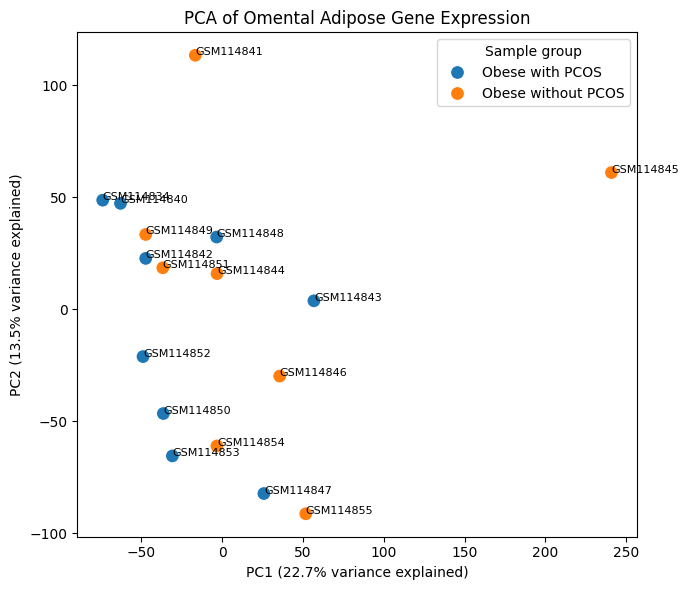

PC1 variance explained: 22.7%
PC2 variance explained: 13.5%
Total variance explained: 36.2%


In [10]:
# PCA
# color labels by group
group_palette = {
    "PCOS": "#1f77b4",       # blue
    "Control": "#ff7f0e"     # orange
}

label_map = {
    "PCOS": "Obese with PCOS",
    "Control": "Obese without PCOS"
}

# PCA input: samples x probes
X = expr_df[sample_cols].T.astype(float)
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)

# Build PCA dataframe using gsm_id, because pheno_df has gsm_id
pca_df = pd.DataFrame({
    "gsm_id": sample_cols,
    "PC1": pcs[:, 0],
    "PC2": pcs[:, 1]
}).merge(pheno_df, on="gsm_id", how="left")

# readable labels
pca_df["group_label"] = pca_df["group"].map(label_map)

# variance explained
pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100

plt.figure(figsize=(7, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="group",
    palette=group_palette,
    s=100
)

# sample labels
for _, r in pca_df.iterrows():
    plt.text(r["PC1"], r["PC2"], r["gsm_id"], fontsize=8)

# clean legend labels
handles, labels = plt.gca().get_legend_handles_labels()
new_labels = [label_map.get(l, l) for l in labels]
plt.legend(handles, new_labels, title="Sample group")

plt.title("PCA of Omental Adipose Gene Expression")
plt.xlabel(f"PC1 ({pc1_var:.1f}% variance explained)")
plt.ylabel(f"PC2 ({pc2_var:.1f}% variance explained)")

plt.tight_layout()
plt.savefig(os.path.join(PLOTDIR, "pca_processed_matrix.png"), dpi=300)
plt.show()

print(f"PC1 variance explained: {pc1_var:.1f}%")
print(f"PC2 variance explained: {pc2_var:.1f}%")
print(f"Total variance explained: {pc1_var + pc2_var:.1f}%")

In [11]:
# Define sample groups from phenotype table
pcos_samples = pheno_df.loc[pheno_df["group"] == "PCOS", "gsm_id"].tolist()
ctrl_samples = pheno_df.loc[pheno_df["group"] == "Control", "gsm_id"].tolist()

print("PCOS samples:", len(pcos_samples))
print("Control samples:", len(ctrl_samples))

# Differential expression: PCOS vs Control
results = []

for _, row in expr_annot.iterrows():
    gene = row['gene_symbol']
    title = row['gene_title']

    if pd.isna(gene):
        continue

    pcos_vals = row[pcos_samples].values.astype(float)
    ctrl_vals = row[ctrl_samples].values.astype(float)

    stat, pval = ttest_ind(pcos_vals, ctrl_vals, equal_var=False)
    logFC = np.log2((np.mean(pcos_vals) + 1) / (np.mean(ctrl_vals) + 1))

    results.append({
        'gene_symbol': gene,
        'gene_title': title,
        'logFC': logFC,
        'P.Value': pval
    })

de_df = pd.DataFrame(results)
de_df['adj.P.Val'] = multipletests(de_df['P.Value'], method='fdr_bh')[1]

print("DE shape:", de_df.shape)

PCOS samples: 9
Control samples: 8
DE shape: (21156, 5)


In [12]:
# Collapse probes to genes
gene_df = de_df.sort_values('P.Value')
gene_df = gene_df.drop_duplicates(subset='gene_symbol', keep='first')

print("Gene-level shape:", gene_df.shape)
gene_df.head(20)

Gene-level shape: (13299, 5)


,gene_symbol,gene_title,logFC,P.Value,adj.P.Val
19311,USP22,ubiquitin specific peptidase 22,1.129425,0.000129,0.8651
2141,GNAQ,G protein subunit alpha q,0.289361,0.000168,0.8651
19858,SERINC3,serine incorporator 3,0.724078,0.000240,0.8651
19505,PPP1R9A,protein phosphatase 1 regulatory subunit 9A,0.374271,0.000241,0.8651
6277,PDE5A,phosphodiesterase 5A,-0.888657,0.000357,0.8651
16508,TMEM248,transmembrane protein 248,-0.314289,0.000389,0.8651
8129,NONO,"non-POU domain containing, octamer-binding",-0.406035,0.000405,0.8651
9022,ACOX1,acyl-CoA oxidase 1,0.354778,0.000795,0.8651
7883,PRPS1,phosphoribosyl pyrophosphate synthetase 1,-0.569927,0.000837,0.8651
10266,IL13RA1,interleukin 13 receptor subunit alpha 1,-0.373998,0.001317,0.8651


In [13]:
# Save tables

expr_df.to_csv(os.path.join(OUTDIR, "processed_expression_matrix.csv"), index=False)
expr_annot.to_csv(os.path.join(OUTDIR, "processed_expression_annotated.csv"), index=False)
de_df.to_csv(os.path.join(OUTDIR, "probe_level_differential_expression.csv"), index=False)
gene_df.to_csv(os.path.join(OUTDIR, "gene_level_differential_expression.csv"), index=False)
pheno_df.to_csv(os.path.join(OUTDIR, "phenotype_table.csv"), index=False)

print("Saved analysis tables.")

Saved analysis tables.


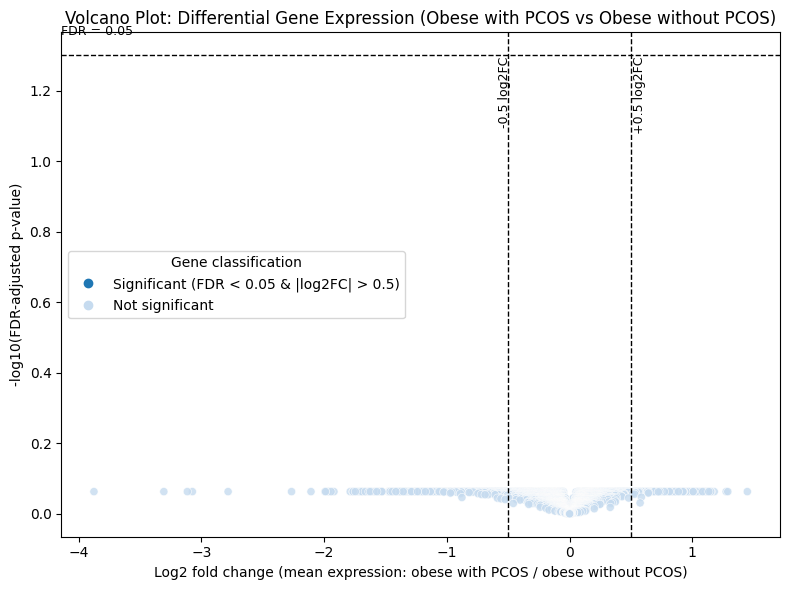

In [14]:
# Volcano plot (FDR on y-axis)

plot_df = gene_df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["logFC", "adj.P.Val"]
).copy()

# compute y-axis (FDR-based)
plot_df["neglog10_fdr"] = -np.log10(plot_df["adj.P.Val"])

# define thresholds
fc_thresh = 0.5
fdr_thresh = 0.05
y_thresh = -np.log10(fdr_thresh)

# define significance groups
plot_df["sig"] = np.where(
    (plot_df["adj.P.Val"] < fdr_thresh) & (np.abs(plot_df["logFC"]) > fc_thresh),
    "FDR < 0.05 & |log2FC| > 0.5",
    "Not significant"
)

# ---- COLOR PALETTE ----
palette = {
    "FDR < 0.05 & |log2FC| > 0.5": "#1f77b4",   # blue
    "Not significant": "#c6dbef"               # light blue
}

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=plot_df,
    x="logFC",
    y="neglog10_fdr",
    hue="sig",
    palette=palette,
    s=35,
    alpha=0.8
)

# ---- Threshold lines ----
plt.axvline(fc_thresh, linestyle="--", color="black", linewidth=1)
plt.axvline(-fc_thresh, linestyle="--", color="black", linewidth=1)
plt.axhline(y_thresh, linestyle="--", color="black", linewidth=1)

# ---- Label dashed lines directly ----
plt.text(fc_thresh + 0.02, plt.ylim()[1]*0.95,
         "+0.5 log2FC", fontsize=9, rotation=90, va="top")

plt.text(-fc_thresh - 0.08, plt.ylim()[1]*0.95,
         "-0.5 log2FC", fontsize=9, rotation=90, va="top")

plt.text(plt.xlim()[0], y_thresh + 0.05,
         "FDR = 0.05", fontsize=9, va="bottom")

# ---- Axis labels ----
plt.xlabel("Log2 fold change (mean expression: obese with PCOS / obese without PCOS)")
plt.ylabel("-log10(FDR-adjusted p-value)")

plt.title("Volcano Plot: Differential Gene Expression (Obese with PCOS vs Obese without PCOS)")

# ---- Custom legend (includes thresholds meaning) ----
import matplotlib.lines as mlines

sig_handle = mlines.Line2D([], [], color="#1f77b4", marker='o', linestyle='None',
                           markersize=6, label="Significant (FDR < 0.05 & |log2FC| > 0.5)")

nonsig_handle = mlines.Line2D([], [], color="#c6dbef", marker='o', linestyle='None',
                              markersize=6, label="Not significant")

plt.legend(handles=[sig_handle, nonsig_handle], title="Gene classification")

plt.tight_layout()
plt.savefig(os.path.join(PLOTDIR, "volcano_plot_final.png"), dpi=300)
plt.show()

Heatmap genes: 50
Heatmap matrix after z-scoring: (50, 17)


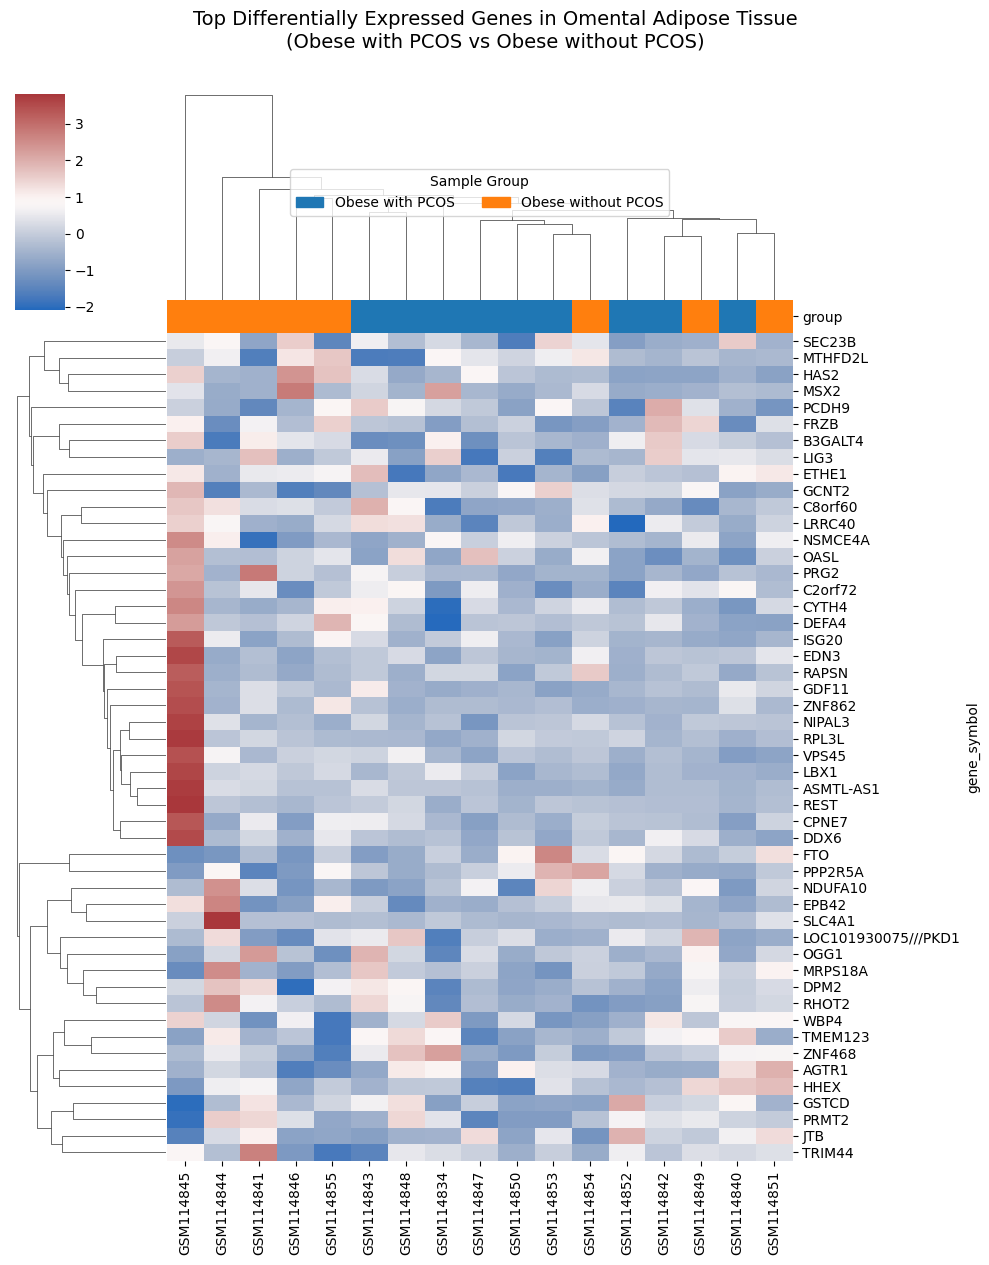

In [15]:
# Heatmap of top genes

top_genes = gene_df.sort_values("adj.P.Val").head(50)["gene_symbol"].dropna().tolist()

heat_df = expr_annot.dropna(subset=["gene_symbol"]).copy()
heat_df = heat_df[heat_df["gene_symbol"].isin(top_genes)].copy()
heat_df = heat_df.sort_values("gene_symbol").drop_duplicates("gene_symbol")

print("Heatmap genes:", heat_df.shape[0])

heat_df = heat_df.set_index("gene_symbol")[sample_cols].astype(float)

# Row-wise z-score normalization
row_means = heat_df.mean(axis=1)
row_stds = heat_df.std(axis=1).replace(0, np.nan)

heat_z = heat_df.sub(row_means, axis=0).div(row_stds, axis=0)
heat_z = heat_z.replace([np.inf, -np.inf], np.nan).dropna()

print("Heatmap matrix after z-scoring:", heat_z.shape)

# Clear group colors that don't conflict with heatmap gradient
group_palette = {
    "PCOS": "#1f77b4",       # blue
    "Control": "#ff7f0e"     # orange
}

col_colors = pheno_df.set_index("gsm_id").loc[heat_z.columns, "group"].map(group_palette)

# Create clustermap
g = sns.clustermap(
    heat_z,
    cmap="vlag",
    col_colors=col_colors,
    figsize=(10, 12),
    xticklabels=True,
    yticklabels=True
)

# Move title higher so it doesn't overlap with dendrogram
g.fig.suptitle(
    "Top Differentially Expressed Genes in Omental Adipose Tissue\n(Obese with PCOS vs Obese without PCOS)",
    fontsize=14,
    y=1.05
)

# Add legend for sample groups
import matplotlib.patches as mpatches

pcos_patch = mpatches.Patch(color="#1f77b4", label="Obese with PCOS")
control_patch = mpatches.Patch(color="#ff7f0e", label="Obese without PCOS")

g.ax_col_dendrogram.legend(
    handles=[pcos_patch, control_patch],
    loc="center",
    ncol=2,
    title="Sample Group"
)

plt.savefig(
    os.path.join(PLOTDIR, "heatmap_top50_processed_matrix.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
# Summary table

# significance threshold
n_sig = ((gene_df["adj.P.Val"] < 0.05) & (np.abs(gene_df["logFC"]) > 0.5)).sum()

summary = pd.DataFrame({
    "metric": [
        "Number of labeled samples",
        "Number of Control samples",
        "Number of PCOS samples",
        "Number of probes tested",
        "Number of genes after collapsing probes",
        "Significant genes (FDR < 0.05 and |logFC| > 0.5)"
    ],
    "value": [
        int(len(sample_cols)),
        int(len(ctrl_samples)),
        int(len(pcos_samples)),
        int(expr_annot.shape[0]),
        int(len(gene_df)),
        int(n_sig)
    ]
})

summary.to_csv(os.path.join(OUTDIR, "summary_table.csv"), index=False)

display(summary)

,metric,value
0,Number of labeled samples,17
1,Number of Control samples,8
2,Number of PCOS samples,9
3,Number of probes tested,22283
4,Number of genes after collapsing probes,13299
5,Significant genes (FDR < 0.05 and |logFC| > 0.5),0


In [17]:
# Top upregulated and downregulated genes

# better ranking: prioritize significance first, then effect
top_up = gene_df.sort_values(
    ["adj.P.Val", "logFC"], ascending=[True, False]
).head(10)

top_down = gene_df.sort_values(
    ["adj.P.Val", "logFC"], ascending=[True, True]
).head(10)

print("Top upregulated genes in PCOS:")
display(top_up[["gene_symbol", "gene_title", "logFC", "P.Value", "adj.P.Val"]])

print("Top downregulated genes in PCOS:")
display(top_down[["gene_symbol", "gene_title", "logFC", "P.Value", "adj.P.Val"]])
# combined ranking score
gene_df["rank_score"] = np.sign(gene_df["logFC"]) * (-np.log10(gene_df["P.Value"] + 1e-300))

top_up = gene_df.sort_values("rank_score", ascending=False).head(10)
top_down = gene_df.sort_values("rank_score", ascending=True).head(10)

Top upregulated genes in PCOS:


,gene_symbol,gene_title,logFC,P.Value,adj.P.Val
13076,LOC100509457///HLA-DQA1,"HLA class II histocompatibility antigen, DQ al...",1.447738,0.043391,0.8651
18513,AHNAK,AHNAK nucleoprotein,1.288419,0.122859,0.8651
8906,HLA-DQB1,"major histocompatibility complex, class II, DQ...",1.275386,0.042093,0.8651
18286,NPR3,natriuretic peptide receptor 3,1.177839,0.012315,0.8651
5493,AADAC,arylacetamide deacetylase,1.153421,0.043902,0.8651
3240,DPP4,dipeptidyl peptidase 4,1.148436,0.249196,0.8651
14195,SCAI,suppressor of cancer cell invasion,1.138328,0.003053,0.8651
20699,CCL18,C-C motif chemokine ligand 18,1.133921,0.320350,0.8651
19311,USP22,ubiquitin specific peptidase 22,1.129425,0.000129,0.8651
4011,KCNQ1,potassium voltage-gated channel subfamily Q me...,1.126008,0.117130,0.8651


Top downregulated genes in PCOS:


,gene_symbol,gene_title,logFC,P.Value,adj.P.Val
9909,INHBA,inhibin beta A subunit,-3.875089,0.114645,0.8651
14241,TRIM58,tripartite motif containing 58,-3.305666,0.331670,0.8651
4138,SERPINB2,serpin family B member 2,-3.114061,0.104510,0.8651
4790,LIF,leukemia inhibitory factor,-3.073416,0.075412,0.8651
10862,ALAS2,5'-aminolevulinate synthase 2,-2.782228,0.321364,0.8651
9506,ARC,activity regulated cytoskeleton associated pro...,-2.265362,0.172530,0.8651
7340,CXCL3,C-X-C motif chemokine ligand 3,-2.107000,0.158817,0.8651
4236,WIF1,WNT inhibitory factor 1,-1.992251,0.340723,0.8651
18573,CCDC134,coiled-coil domain containing 134,-1.988264,0.362606,0.8651
3944,FOSL1,"FOS like 1, AP-1 transcription factor subunit",-1.967008,0.157177,0.8651


In [18]:
# Save significant genes for downstream pathway analysis
sig_genes = gene_df[
    (gene_df["adj.P.Val"] < 0.05) &
    (np.abs(gene_df["logFC"]) > 0.5)
][["gene_symbol", "gene_title", "logFC", "adj.P.Val"]]

# clean + deduplicate
sig_genes["gene_symbol"] = sig_genes["gene_symbol"].astype(str).str.strip().str.upper()
sig_genes = sig_genes.drop_duplicates(subset="gene_symbol")

sig_genes.to_csv(
    os.path.join(OUTDIR, "significant_genes_for_pathway_analysis.csv"),
    index=False
)

print(f"Saved {len(sig_genes)} significant genes.")
display(sig_genes.head(20))

Saved 0 significant genes.


,gene_symbol,gene_title,logFC,adj.P.Val


In [19]:
# --- List output files ---
for root, dirs, files in os.walk(OUTDIR):
    for f in sorted(files):
        print(os.path.join(root, f))

/content/gse5090_series_pipeline/results/gene_level_differential_expression.csv
/content/gse5090_series_pipeline/results/phenotype_table.csv
/content/gse5090_series_pipeline/results/probe_level_differential_expression.csv
/content/gse5090_series_pipeline/results/processed_expression_annotated.csv
/content/gse5090_series_pipeline/results/processed_expression_matrix.csv
/content/gse5090_series_pipeline/results/significant_genes_for_pathway_analysis.csv
/content/gse5090_series_pipeline/results/summary_table.csv
/content/gse5090_series_pipeline/results/plots/heatmap_top50_processed_matrix.png
/content/gse5090_series_pipeline/results/plots/pca_processed_matrix.png
/content/gse5090_series_pipeline/results/plots/volcano_plot_final.png


In [20]:
#Prepare ranked gene list for pathway analysis

# Rebuild ranked list fresh right before GSEA

rank_df = gene_df.copy()

rank_df["gene_symbol"] = rank_df["gene_symbol"].astype(str).str.strip().str.upper()

# remove missing / bad symbols
rank_df = rank_df[~rank_df["gene_symbol"].isin(["", "---", "NAN"])]
rank_df = rank_df[~rank_df["gene_symbol"].str.contains("///", na=False)]

# keep one row per gene
rank_df = rank_df.sort_values("P.Value").drop_duplicates(subset="gene_symbol", keep="first")

# ranking score
rank_df["rank_score"] = np.sign(rank_df["logFC"]) * (-np.log10(rank_df["P.Value"] + 1e-300))

# final preranked dataframe
rnk = rank_df[["gene_symbol", "rank_score"]].sort_values("rank_score", ascending=False).reset_index(drop=True)

print("Number of ranked genes going into GSEA:", len(rnk))
display(rnk.head(20))

print(rnk.head(5).to_dict("records"))

Number of ranked genes going into GSEA: 12501


,gene_symbol,rank_score
0,USP22,3.889202
1,GNAQ,3.773779
2,SERINC3,3.619006
3,PPP1R9A,3.618851
4,ACOX1,3.099503
5,KDM5A,2.876463
6,GLB1L,2.848977
7,SYNC,2.808791
8,VEZF1,2.794875
9,PHACTR2,2.782992


[{'gene_symbol': 'USP22', 'rank_score': 3.8892021403746826}, {'gene_symbol': 'GNAQ', 'rank_score': 3.773779124903346}, {'gene_symbol': 'SERINC3', 'rank_score': 3.6190064331014296}, {'gene_symbol': 'PPP1R9A', 'rank_score': 3.618851094772515}, {'gene_symbol': 'ACOX1', 'rank_score': 3.0995034367200107}]


In [21]:
#Run GSEA
!pip install gseapy
import gseapy as gp

rnk_fresh = rank_df[["gene_symbol", "rank_score"]].sort_values(
    "rank_score", ascending=False
).reset_index(drop=True)

print("Fresh ranked genes going into GSEA:", len(rnk_fresh))
print(rnk_fresh.head(5).to_dict("records"))

import gseapy as gp

pre_res_hallmark = gp.prerank(
    rnk=rnk_fresh,
    gene_sets="MSigDB_Hallmark_2020",
    min_size=5,
    max_size=1000,
    permutation_num=100,
    outdir=None,
    seed=42,
    verbose=True
)

hallmark_results = pre_res_hallmark.res2d.sort_values("FDR q-val")
display(hallmark_results.head(15))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 634.7/634.7 kB 20.1 MB/s eta 0:00:00


2026-05-11 18:29:45,682 [INFO] Parsing data files for GSEA.............................
2026-05-11 18:29:45,743 [INFO] Downloading and generating Enrichr library gene sets......
2026-05-11 18:29:45,763 [INFO] 0000 gene_sets have been filtered out when max_size=1000 and min_size=5
2026-05-11 18:29:45,764 [INFO] 0050 gene_sets used for further statistical testing.....
2026-05-11 18:29:45,765 [INFO] Start to run GSEA...Might take a while..................


Fresh ranked genes going into GSEA: 12501
[{'gene_symbol': 'USP22', 'rank_score': 3.8892021403746826}, {'gene_symbol': 'GNAQ', 'rank_score': 3.773779124903346}, {'gene_symbol': 'SERINC3', 'rank_score': 3.6190064331014296}, {'gene_symbol': 'PPP1R9A', 'rank_score': 3.618851094772515}, {'gene_symbol': 'ACOX1', 'rank_score': 3.0995034367200107}]


2026-05-11 18:29:46,481 [INFO] Congratulations. GSEApy runs successfully................



,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Adipogenesis,0.439687,2.169627,0.010000,0.010000,0.01,64/170,19.89%,ACOX1;SSPN;TST;ME1;ESYT1;SCARB1;RREB1;SCP2;RTN...
1,prerank,Oxidative Phosphorylation,0.381338,1.961182,0.010000,0.010000,0.01,88/180,26.41%,COX7A2L;UQCR10;PDP1;MDH1;ATP6V0E1;UQCRQ;SLC25A...
2,prerank,Inflammatory Response,-0.391562,-1.807677,0.010000,0.010000,0.01,76/194,24.88%,PSEN1;SLC11A2;MET;CSF1;CXCL9;BEST1;ADORA2B;CD4...
3,prerank,Epithelial Mesenchymal Transition,-0.379172,-1.792822,0.010000,0.010000,0.02,85/190,26.25%,ACTA2;NOTCH2;MATN3;CD44;COPA;CADM1;PTHLH;LRRC1...
7,prerank,Fatty Acid Metabolism,0.323826,1.541255,0.010000,0.010000,0.02,54/144,23.00%,ACOX1;ME1;NBN;NTHL1;ALDH3A2;EHHADH;ALDH9A1;CD3...
6,prerank,Protein Secretion,0.346634,1.593872,0.010000,0.010000,0.01,38/94,18.29%,SCRN1;SSPN;CLCN3;VPS4B;YIPF6;RAB2A;VAMP3;RAB14...
5,prerank,IL-6/JAK/STAT3 Signaling,-0.402626,-1.672185,0.010000,0.011354,0.05,49/86,36.58%,IL13RA1;CD44;CRLF2;STAT1;PTPN11;CSF1;CXCL9;LTB...
4,prerank,TNF-alpha Signaling via NF-kB,-0.361222,-1.682691,0.010000,0.015138,0.05,96/194,31.15%,CFLAR;CD44;CSF1;TNC;SPSB1;LIF;EDN1;TNIP2;NFKB2...
8,prerank,UV Response Dn,0.323027,1.501957,0.010000,0.019156,0.08,31/136,9.34%,NR1D2;CELF2;VLDLR;TGFBR3;SMAD3;ATRX;NIPBL;CDK1...
14,prerank,Reactive Oxygen Species Pathway,0.354567,1.383933,0.058824,0.069838,0.29,16/44,18.93%,NQO1;MSRA;LAMTOR5;FTL;PRDX2;PRDX6;SOD1;ABCC1;G...


In [22]:
# Save Hallmark GSEA results
hallmark_results.to_csv(os.path.join(OUTDIR, "gsea_hallmark_results.csv"), index=False)

print("Saved Hallmark GSEA results.")
display(hallmark_results.head(20))

Saved Hallmark GSEA results.


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Adipogenesis,0.439687,2.169627,0.010000,0.010000,0.01,64/170,19.89%,ACOX1;SSPN;TST;ME1;ESYT1;SCARB1;RREB1;SCP2;RTN...
1,prerank,Oxidative Phosphorylation,0.381338,1.961182,0.010000,0.010000,0.01,88/180,26.41%,COX7A2L;UQCR10;PDP1;MDH1;ATP6V0E1;UQCRQ;SLC25A...
2,prerank,Inflammatory Response,-0.391562,-1.807677,0.010000,0.010000,0.01,76/194,24.88%,PSEN1;SLC11A2;MET;CSF1;CXCL9;BEST1;ADORA2B;CD4...
3,prerank,Epithelial Mesenchymal Transition,-0.379172,-1.792822,0.010000,0.010000,0.02,85/190,26.25%,ACTA2;NOTCH2;MATN3;CD44;COPA;CADM1;PTHLH;LRRC1...
7,prerank,Fatty Acid Metabolism,0.323826,1.541255,0.010000,0.010000,0.02,54/144,23.00%,ACOX1;ME1;NBN;NTHL1;ALDH3A2;EHHADH;ALDH9A1;CD3...
6,prerank,Protein Secretion,0.346634,1.593872,0.010000,0.010000,0.01,38/94,18.29%,SCRN1;SSPN;CLCN3;VPS4B;YIPF6;RAB2A;VAMP3;RAB14...
5,prerank,IL-6/JAK/STAT3 Signaling,-0.402626,-1.672185,0.010000,0.011354,0.05,49/86,36.58%,IL13RA1;CD44;CRLF2;STAT1;PTPN11;CSF1;CXCL9;LTB...
4,prerank,TNF-alpha Signaling via NF-kB,-0.361222,-1.682691,0.010000,0.015138,0.05,96/194,31.15%,CFLAR;CD44;CSF1;TNC;SPSB1;LIF;EDN1;TNIP2;NFKB2...
8,prerank,UV Response Dn,0.323027,1.501957,0.010000,0.019156,0.08,31/136,9.34%,NR1D2;CELF2;VLDLR;TGFBR3;SMAD3;ATRX;NIPBL;CDK1...
14,prerank,Reactive Oxygen Species Pathway,0.354567,1.383933,0.058824,0.069838,0.29,16/44,18.93%,NQO1;MSRA;LAMTOR5;FTL;PRDX2;PRDX6;SOD1;ABCC1;G...


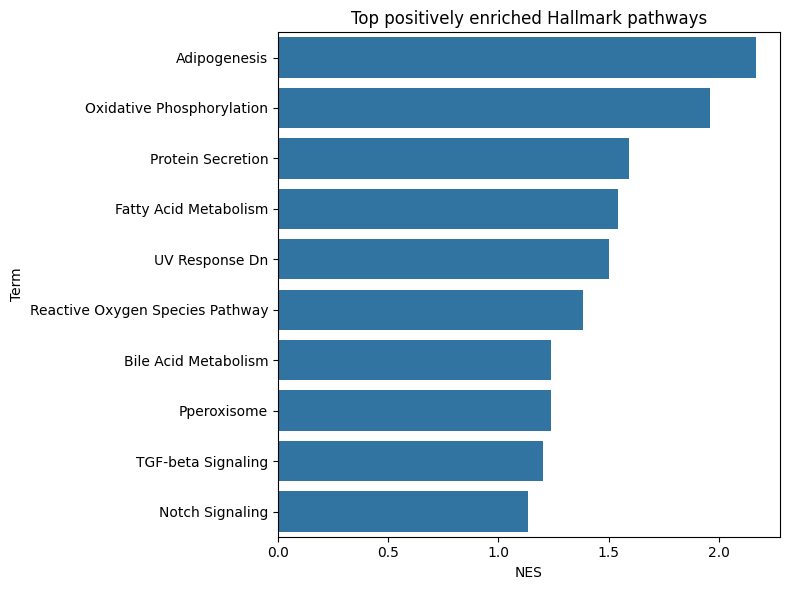

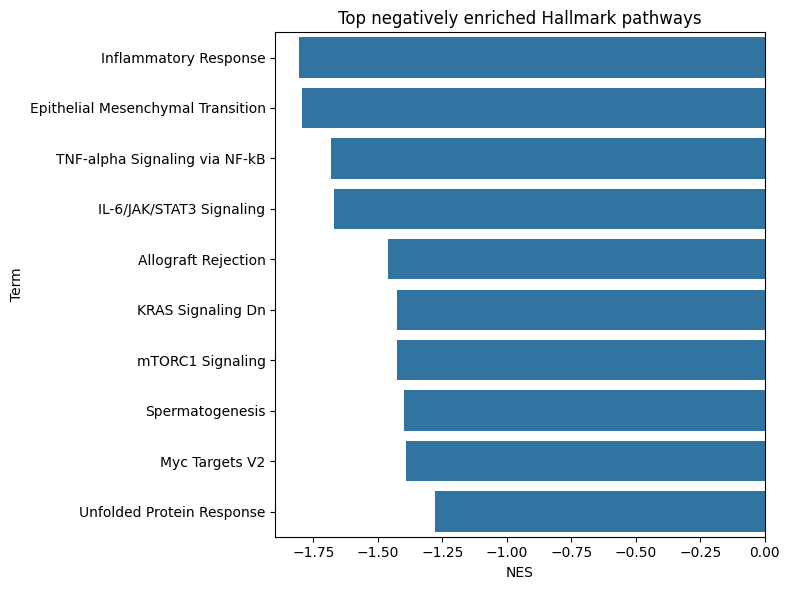

In [23]:
# Separate positive and negative NES pathways
top_pos = hallmark_results.sort_values("NES", ascending=False).head(10)
top_neg = hallmark_results.sort_values("NES", ascending=True).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(data=top_pos, x="NES", y="Term")
plt.title("Top positively enriched Hallmark pathways")
plt.tight_layout()
plt.savefig(os.path.join(PLOTDIR, "gsea_top_positive_hallmark.png"), dpi=300)
plt.show()

plt.figure(figsize=(8, 6))
sns.barplot(data=top_neg, x="NES", y="Term")
plt.title("Top negatively enriched Hallmark pathways")
plt.tight_layout()
plt.savefig(os.path.join(PLOTDIR, "gsea_top_negative_hallmark.png"), dpi=300)
plt.show()

In [24]:
# Extract leading-edge genes from top Hallmark pathways

top_terms = hallmark_results.head(10)[["Term", "Lead_genes", "NES", "FDR q-val"]].copy()
display(top_terms)

leading_edge_rows = []
for _, row in top_terms.iterrows():
    term = row["Term"]
    nes = row["NES"]
    fdr = row["FDR q-val"]
    genes = str(row["Lead_genes"]).split(";")
    for gene in genes:
        leading_edge_rows.append({
            "Pathway": term,
            "NES": nes,
            "FDR_q_val": fdr,
            "Gene": gene
        })

leading_edge_df = pd.DataFrame(leading_edge_rows)
leading_edge_df.to_csv(os.path.join(OUTDIR, "leading_edge_genes_top_hallmark.csv"), index=False)

print("Saved leading-edge genes.")
display(leading_edge_df.head(30))

,Term,Lead_genes,NES,FDR q-val
0,Adipogenesis,ACOX1;SSPN;TST;ME1;ESYT1;SCARB1;RREB1;SCP2;RTN...,2.169627,0.010000
1,Oxidative Phosphorylation,COX7A2L;UQCR10;PDP1;MDH1;ATP6V0E1;UQCRQ;SLC25A...,1.961182,0.010000
2,Inflammatory Response,PSEN1;SLC11A2;MET;CSF1;CXCL9;BEST1;ADORA2B;CD4...,-1.807677,0.010000
3,Epithelial Mesenchymal Transition,ACTA2;NOTCH2;MATN3;CD44;COPA;CADM1;PTHLH;LRRC1...,-1.792822,0.010000
7,Fatty Acid Metabolism,ACOX1;ME1;NBN;NTHL1;ALDH3A2;EHHADH;ALDH9A1;CD3...,1.541255,0.010000
6,Protein Secretion,SCRN1;SSPN;CLCN3;VPS4B;YIPF6;RAB2A;VAMP3;RAB14...,1.593872,0.010000
5,IL-6/JAK/STAT3 Signaling,IL13RA1;CD44;CRLF2;STAT1;PTPN11;CSF1;CXCL9;LTB...,-1.672185,0.011354
4,TNF-alpha Signaling via NF-kB,CFLAR;CD44;CSF1;TNC;SPSB1;LIF;EDN1;TNIP2;NFKB2...,-1.682691,0.015138
8,UV Response Dn,NR1D2;CELF2;VLDLR;TGFBR3;SMAD3;ATRX;NIPBL;CDK1...,1.501957,0.019156
14,Reactive Oxygen Species Pathway,NQO1;MSRA;LAMTOR5;FTL;PRDX2;PRDX6;SOD1;ABCC1;G...,1.383933,0.069838


Saved leading-edge genes.


,Pathway,NES,FDR_q_val,Gene
0,Adipogenesis,2.169627,0.01,ACOX1
1,Adipogenesis,2.169627,0.01,SSPN
2,Adipogenesis,2.169627,0.01,TST
3,Adipogenesis,2.169627,0.01,ME1
4,Adipogenesis,2.169627,0.01,ESYT1
5,Adipogenesis,2.169627,0.01,SCARB1
6,Adipogenesis,2.169627,0.01,RREB1
7,Adipogenesis,2.169627,0.01,SCP2
8,Adipogenesis,2.169627,0.01,RTN3
9,Adipogenesis,2.169627,0.01,UQCR10


In [25]:
# Save top positive and negative Hallmark pathways separately

top_pos = hallmark_results.sort_values("NES", ascending=False).head(10)
top_neg = hallmark_results.sort_values("NES", ascending=True).head(10)

top_pos.to_csv(os.path.join(OUTDIR, "gsea_top_positive_hallmark.csv"), index=False)
top_neg.to_csv(os.path.join(OUTDIR, "gsea_top_negative_hallmark.csv"), index=False)

display(top_pos)
display(top_neg)
# Leading-edge genes for top positive and negative pathways

lead_pos_rows = []
for _, row in top_pos.iterrows():
    for gene in str(row["Lead_genes"]).split(";"):
        lead_pos_rows.append({
            "Pathway": row["Term"],
            "NES": row["NES"],
            "FDR_q_val": row["FDR q-val"],
            "Gene": gene
        })

lead_neg_rows = []
for _, row in top_neg.iterrows():
    for gene in str(row["Lead_genes"]).split(";"):
        lead_neg_rows.append({
            "Pathway": row["Term"],
            "NES": row["NES"],
            "FDR_q_val": row["FDR q-val"],
            "Gene": gene
        })

lead_pos_df = pd.DataFrame(lead_pos_rows)
lead_neg_df = pd.DataFrame(lead_neg_rows)

lead_pos_df.to_csv(os.path.join(OUTDIR, "leading_edge_genes_positive_pathways.csv"), index=False)
lead_neg_df.to_csv(os.path.join(OUTDIR, "leading_edge_genes_negative_pathways.csv"), index=False)

display(lead_pos_df.head(30))
display(lead_neg_df.head(30))

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Adipogenesis,0.439687,2.169627,0.010000,0.010000,0.01,64/170,19.89%,ACOX1;SSPN;TST;ME1;ESYT1;SCARB1;RREB1;SCP2;RTN...
1,prerank,Oxidative Phosphorylation,0.381338,1.961182,0.010000,0.010000,0.01,88/180,26.41%,COX7A2L;UQCR10;PDP1;MDH1;ATP6V0E1;UQCRQ;SLC25A...
6,prerank,Protein Secretion,0.346634,1.593872,0.010000,0.010000,0.01,38/94,18.29%,SCRN1;SSPN;CLCN3;VPS4B;YIPF6;RAB2A;VAMP3;RAB14...
7,prerank,Fatty Acid Metabolism,0.323826,1.541255,0.010000,0.010000,0.02,54/144,23.00%,ACOX1;ME1;NBN;NTHL1;ALDH3A2;EHHADH;ALDH9A1;CD3...
8,prerank,UV Response Dn,0.323027,1.501957,0.010000,0.019156,0.08,31/136,9.34%,NR1D2;CELF2;VLDLR;TGFBR3;SMAD3;ATRX;NIPBL;CDK1...
14,prerank,Reactive Oxygen Species Pathway,0.354567,1.383933,0.058824,0.069838,0.29,16/44,18.93%,NQO1;MSRA;LAMTOR5;FTL;PRDX2;PRDX6;SOD1;ABCC1;G...
17,prerank,Bile Acid Metabolism,0.275278,1.241318,0.103448,0.237735,0.76,25/99,14.61%,PEX1;SCP2;ALDH9A1;OPTN;ABCA8;ABCD3;PEX16;PEX19...
18,prerank,Pperoxisome,0.250239,1.237548,0.083333,0.209515,0.77,22/96,14.61%,ACOX1;VPS4B;HRAS;EHHADH;SCP2;ALDH9A1;CTBP1;STS...
19,prerank,TGF-beta Signaling,0.296797,1.200853,0.083333,0.230134,0.85,12/51,11.50%,TRIM33;SMAD3;BMPR1A;TJP1;CDKN1C;PMEPA1;SMURF2;...
25,prerank,Notch Signaling,0.322138,1.13378,0.263158,0.359168,0.97,10/28,12.59%,PSENEN;CCND1;SAP30;PPARD;PSEN2;APH1A;FZD7;TCF7...


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
2,prerank,Inflammatory Response,-0.391562,-1.807677,0.010000,0.010000,0.01,76/194,24.88%,PSEN1;SLC11A2;MET;CSF1;CXCL9;BEST1;ADORA2B;CD4...
3,prerank,Epithelial Mesenchymal Transition,-0.379172,-1.792822,0.010000,0.010000,0.02,85/190,26.25%,ACTA2;NOTCH2;MATN3;CD44;COPA;CADM1;PTHLH;LRRC1...
4,prerank,TNF-alpha Signaling via NF-kB,-0.361222,-1.682691,0.010000,0.015138,0.05,96/194,31.15%,CFLAR;CD44;CSF1;TNC;SPSB1;LIF;EDN1;TNIP2;NFKB2...
5,prerank,IL-6/JAK/STAT3 Signaling,-0.402626,-1.672185,0.010000,0.011354,0.05,49/86,36.58%,IL13RA1;CD44;CRLF2;STAT1;PTPN11;CSF1;CXCL9;LTB...
9,prerank,Allograft Rejection,-0.298545,-1.461896,0.010000,0.072663,0.35,72/192,30.17%,IKBKB;EGFR;STAT1;CSF1;CXCL9;ETS1;CD40;LTB;ELF4...
10,prerank,KRAS Signaling Dn,-0.310321,-1.425119,0.015152,0.083260,0.44,58/191,24.38%,CLDN16;PTPRJ;SLC6A3;ACTC1;DTNB;NRIP2;CACNA1F;T...
11,prerank,mTORC1 Signaling,-0.3068,-1.42453,0.010000,0.071366,0.44,57/189,18.71%,ENO1;SYTL2;HSPA5;SQLE;HSPD1;TOMM40;HMGCR;IGFBP...
12,prerank,Spermatogenesis,-0.315331,-1.398439,0.030303,0.096506,0.60,42/122,21.35%,MTOR;CDKN3;CDK1;NF2;AKAP4;GRM8;HSPA4L;LPIN1;DM...
13,prerank,Myc Targets V2,-0.362638,-1.389754,0.081967,0.092848,0.62,27/55,29.73%,WDR74;DDX18;HSPD1;PUS1;RRP9;MCM4;SLC19A1;NOP2;...
15,prerank,Unfolded Protein Response,-0.3067,-1.278787,0.074627,0.217990,0.90,35/104,20.09%,FUS;HSPA5;GOSR2;YWHAZ;SPCS3;XBP1;PSAT1;EIF4G1;...


,Pathway,NES,FDR_q_val,Gene
0,Adipogenesis,2.169627,0.01,ACOX1
1,Adipogenesis,2.169627,0.01,SSPN
2,Adipogenesis,2.169627,0.01,TST
3,Adipogenesis,2.169627,0.01,ME1
4,Adipogenesis,2.169627,0.01,ESYT1
5,Adipogenesis,2.169627,0.01,SCARB1
6,Adipogenesis,2.169627,0.01,RREB1
7,Adipogenesis,2.169627,0.01,SCP2
8,Adipogenesis,2.169627,0.01,RTN3
9,Adipogenesis,2.169627,0.01,UQCR10


,Pathway,NES,FDR_q_val,Gene
0,Inflammatory Response,-1.807677,0.01,PSEN1
1,Inflammatory Response,-1.807677,0.01,SLC11A2
2,Inflammatory Response,-1.807677,0.01,MET
3,Inflammatory Response,-1.807677,0.01,CSF1
4,Inflammatory Response,-1.807677,0.01,CXCL9
5,Inflammatory Response,-1.807677,0.01,BEST1
6,Inflammatory Response,-1.807677,0.01,ADORA2B
7,Inflammatory Response,-1.807677,0.01,CD40
8,Inflammatory Response,-1.807677,0.01,ATP2A2
9,Inflammatory Response,-1.807677,0.01,SLC7A2


In [26]:
# TF enrichment on top upregulated genes

top_up_genes = rank_df.sort_values("rank_score", ascending=False).head(300)["gene_symbol"].tolist()

tf_up = gp.enrichr(
    gene_list=top_up_genes,
    gene_sets=["ChEA_2016"],
    outdir=None
)

tf_up_results = tf_up.results.sort_values("Adjusted P-value")
display(tf_up_results.head(20))
tf_up_results.to_csv(os.path.join(OUTDIR, "tf_enrichment_upregulated.csv"), index=False)
# TF enrichment on top downregulated genes

top_down_genes = rank_df.sort_values("rank_score", ascending=True).head(300)["gene_symbol"].tolist()

tf_down = gp.enrichr(
    gene_list=top_down_genes,
    gene_sets=["ChEA_2016"],
    outdir=None
)

tf_down_results = tf_down.results.sort_values("Adjusted P-value")
display(tf_down_results.head(20))
tf_down_results.to_csv(os.path.join(OUTDIR, "tf_enrichment_downregulated.csv"), index=False)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,ChEA_2016,HNF4A 19822575 ChIP-Seq HepG2 Human,148/6083,4.020896e-12,2.557290e-09,0,0,2.258258,59.255606,NCKAP1;SCARB1;GMFB;ZFYVE9;CSE1L;ZFAND6;ZBTB20;...
1,ChEA_2016,NUCKS1 24931609 ChIP-Seq HEPATOCYTES Mouse,28/588,7.996667e-08,2.542940e-05,0,0,3.518382,57.496194,NCKAP1;CSE1L;UBE3A;PIK3R1;WASL;MTDH;YY1;SESN1;...
2,ChEA_2016,CREB1 23762244 ChIP-Seq HIPPOCAMPUS Rat,67/2393,2.676711e-07,4.770701e-05,0,0,2.147875,32.504880,KDM5A;POP4;CSE1L;ZFAND6;ZBTB20;YY1;NIPBL;SLC39...
3,ChEA_2016,PPARG 20887899 ChIP-Seq 3T3-L1 Mouse,89/3565,3.000441e-07,4.770701e-05,0,0,1.968728,29.568988,KDM5A;CLIC5;DENND1B;SCARB1;CNTNAP2;YWHAB;POP4;...
4,ChEA_2016,CHD1 26751641 Chip-Seq LNCaP Human,56/2000,3.247297e-06,4.130562e-04,0,0,2.096269,26.491996,NCKAP1;ZFYVE9;KIAA1033;CHD4;F11R;PPP1R9A;SCP2;...
5,ChEA_2016,WT1 25993318 ChIP-Seq PODOCYTE Human,81/3464,1.657267e-05,1.756703e-03,0,0,1.783936,19.637129,NCKAP1;CLIC5;DENND1B;SCARB1;CELF2;QPRT;WBP1L;Z...
6,ChEA_2016,KDM5B 21448134 ChIP-Seq MESCs Mouse,85/3724,2.365751e-05,2.149454e-03,0,0,1.744902,18.586397,KDM5A;NCKAP1;CNTNAP2;CSE1L;UBE3A;CHD4;WASL;ITG...
7,ChEA_2016,ZFX 18555785 ChIP-Seq MESCs Mouse,76/3249,3.312542e-05,2.633471e-03,0,0,1.767216,18.229199,NCKAP1;YWHAB;RNF14;CSE1L;ZFAND6;QPRT;UBE3A;WAS...
8,ChEA_2016,DMRT1 23473982 ChIP-Seq TESTES Mouse,54/2072,3.826210e-05,2.657306e-03,0,0,1.923397,19.562966,NCKAP1;YWHAB;ZBTB20;CHD4;ITGAE;F11R;SLC4A4;YY1...
9,ChEA_2016,RUNX1 21571218 ChIP-Seq MEGAKARYOCYTES Human,107/5071,4.178154e-05,2.657306e-03,0,0,1.645790,16.594588,SCARB1;ZFYVE9;CSE1L;ZBTB20;F11R;YY1;CCDC91;GOL...


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,ChEA_2016,BACH1 22875853 ChIP-PCR HELA AND SCP4 Human,45/1352,3.904788e-07,0.000246,0,0,2.483415,36.645005,PHTF2;VAC14;POM121;LTK;STEAP4;EDA;CSF1;SDC2;GR...
1,ChEA_2016,NUCKS1 24931609 ChIP-Seq HEPATOCYTES Mouse,24/588,9.936100e-06,0.002760,0,0,2.950355,33.986126,DDX18;SREBF1;CSF1;CBFB;STAT1;POLDIP3;PTPRJ;SLC...
2,ChEA_2016,KDM5B 21448134 ChIP-Seq MESCs Mouse,86/3724,1.314180e-05,0.002760,0,0,1.774278,19.942372,RBM28;PHTF2;DIDO1;ANKLE2;DDX3X;WDR1;FASTKD2;DO...
3,ChEA_2016,RELA 24523406 ChIP-Seq FIBROSARCOMA Human,33/1182,4.457497e-04,0.058658,0,0,1.995492,15.396723,APP;ANKLE2;CLIC4;CXCL9;CSF1;SRRT;SLC3A2;ENO1;P...
5,ChEA_2016,SMAD2 18955504 ChIP-ChIP HaCaT Human,47/1936,6.517520e-04,0.058658,0,0,1.751595,12.849432,NOTCH2;APP;TMEM87A;MTMR1;DIDO1;HSP90AB1;SLC35D...
4,ChEA_2016,SMAD 19615063 ChIP-ChIP OVARY Human,8/124,5.714766e-04,0.058658,0,0,4.625413,34.539289,RGS17;KLF12;SPATA5L1;ADORA2B;CSNK1A1;CFLAR;PTH...
6,ChEA_2016,SMAD3 18955504 ChIP-ChIP HaCaT Human,47/1936,6.517520e-04,0.058658,0,0,1.751595,12.849432,NOTCH2;APP;TMEM87A;MTMR1;DIDO1;HSP90AB1;SLC35D...
7,ChEA_2016,HNF4A 19822575 ChIP-Seq HepG2 Human,117/6083,8.699246e-04,0.068507,0,0,1.471799,10.371922,FAM49A;CLDN1;BZW1;CRKL;BEST1;SAMD14;PSMD4;CDH2...
8,ChEA_2016,DCP1A 22483619 ChIP-Seq HELA Human,22/759,2.566314e-03,0.179642,0,0,2.036186,12.146429,NOTCH2;DIDO1;VAC14;FASTKD2;FUS;API5;POLDIP3;GO...
9,ChEA_2016,EKLF 21900194 ChIP-Seq ERYTHROCYTE Mouse,31/1239,3.668731e-03,0.231130,0,0,1.764113,9.892985,RBM28;VAC14;DCTN5;POM121;COPA;TOMM40;WDR1;POLD...


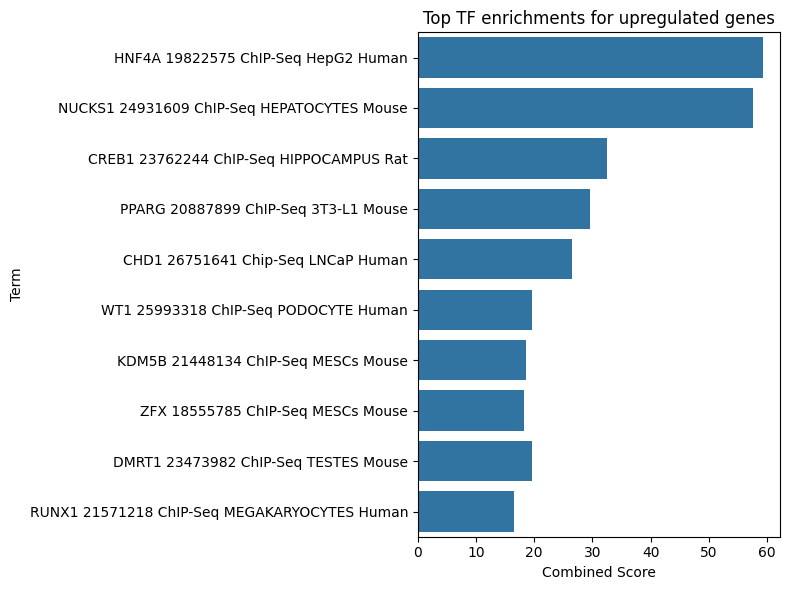

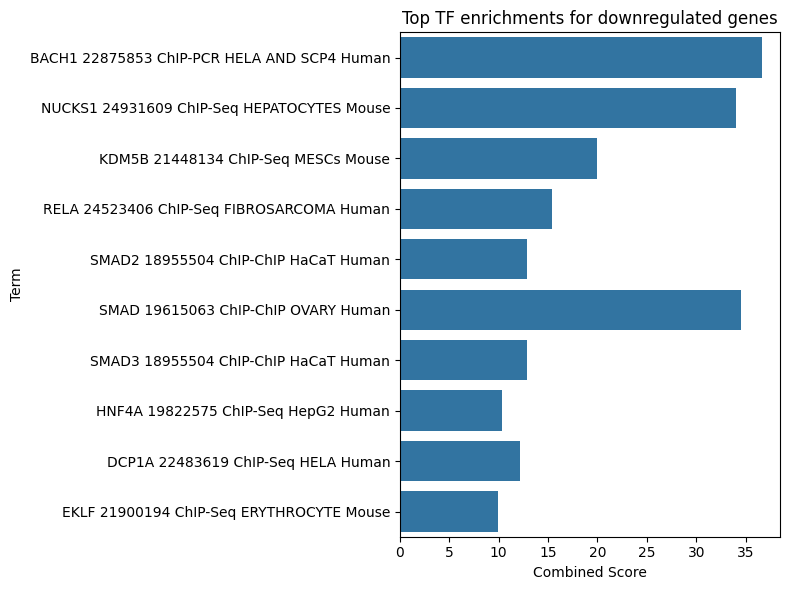

In [27]:
# Plot top TFs for upregulated genes

tf_up_plot = tf_up_results.head(10).copy()

plt.figure(figsize=(8, 6))
sns.barplot(data=tf_up_plot, x="Combined Score", y="Term")
plt.title("Top TF enrichments for upregulated genes")
plt.tight_layout()
plt.savefig(os.path.join(PLOTDIR, "tf_enrichment_upregulated_barplot.png"), dpi=300)
plt.show()
# Plot top TFs for downregulated genes

tf_down_plot = tf_down_results.head(10).copy()

plt.figure(figsize=(8, 6))
sns.barplot(data=tf_down_plot, x="Combined Score", y="Term")
plt.title("Top TF enrichments for downregulated genes")
plt.tight_layout()
plt.savefig(os.path.join(PLOTDIR, "tf_enrichment_downregulated_barplot.png"), dpi=300)
plt.show()

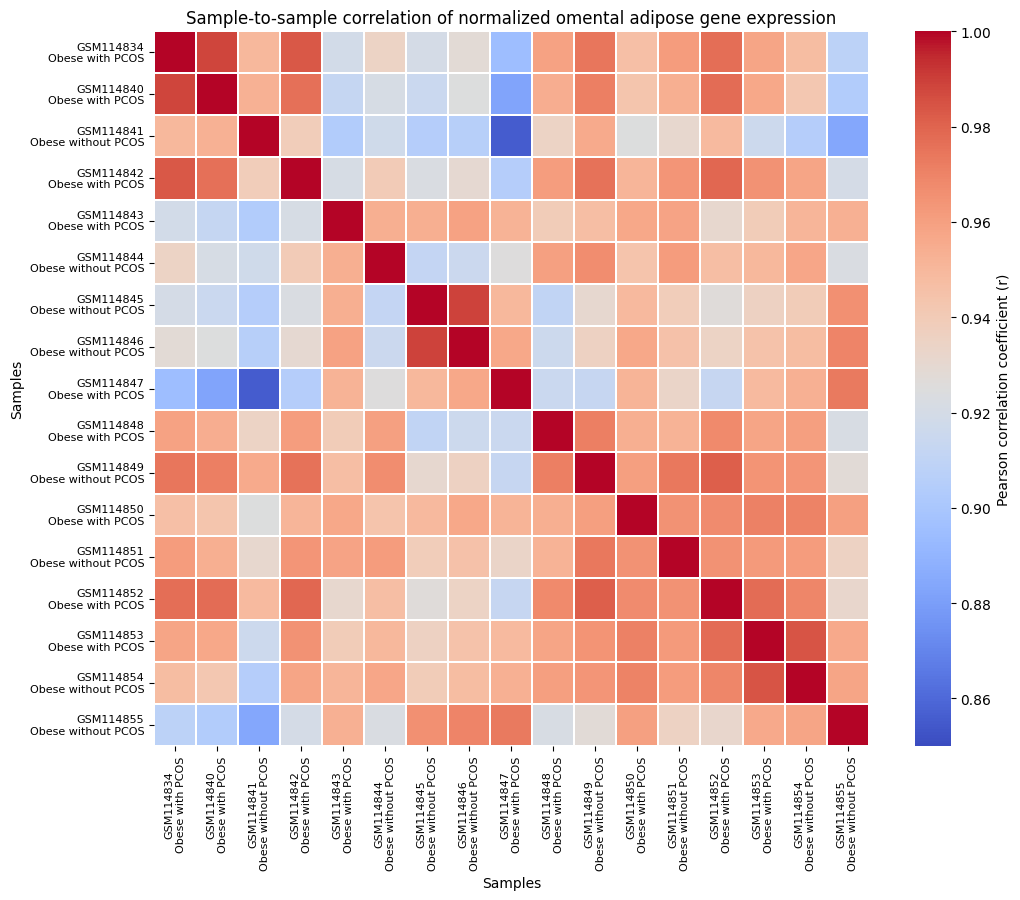

In [28]:
# Sample-to-sample correlation heatmap

# readable sample labels: GSM ID + group
label_map = {
    "PCOS": "Obese with PCOS",
    "Control": "Obese without PCOS"
}

sample_labels = (
    pheno_df.set_index("gsm_id")
    .loc[sample_cols]
    .assign(group_label=lambda d: d["group"].map(label_map))
)

new_labels = [
    f"{idx}\n{row['group_label']}"
    for idx, row in sample_labels.iterrows()
]

# correlation matrix
sample_expr = expr_annot[sample_cols].copy()
sample_corr = sample_expr.corr()

# replace row/column labels with descriptive labels
sample_corr_labeled = sample_corr.copy()
sample_corr_labeled.index = new_labels
sample_corr_labeled.columns = new_labels

plt.figure(figsize=(11, 9))

sns.heatmap(
    sample_corr_labeled,
    cmap="coolwarm",
    vmin=0.85,
    vmax=1.0,
    square=True,
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Pearson correlation coefficient (r)"}
)

plt.title("Sample-to-sample correlation of normalized omental adipose gene expression")
plt.xlabel("Samples")
plt.ylabel("Samples")

plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig(
    os.path.join(PLOTDIR, "sample_correlation_heatmap_labeled.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

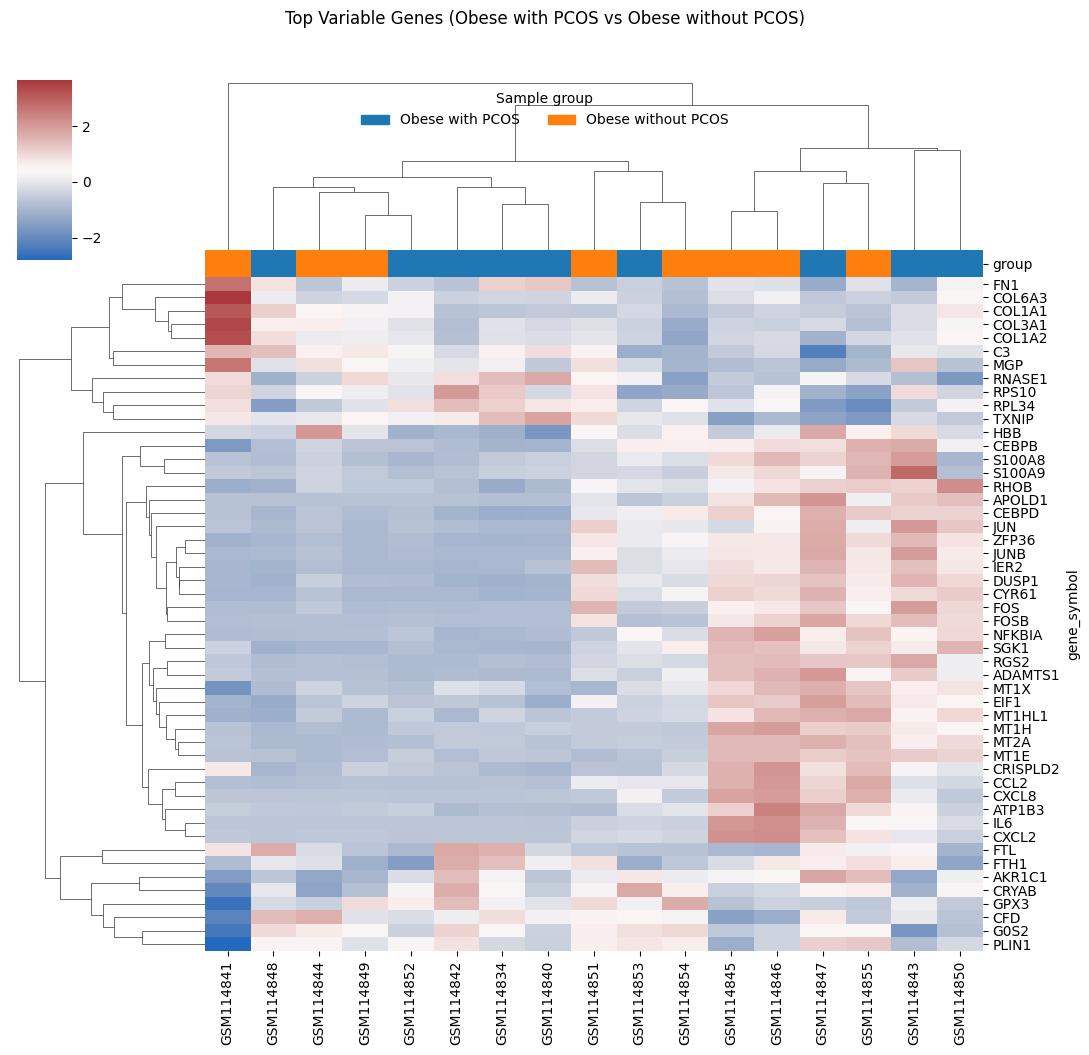

In [29]:
# Heatmap of most variable genes with donor/sample group annotation

expr_gene = expr_annot.dropna(subset=["gene_symbol"]).copy()
expr_gene["gene_symbol"] = expr_gene["gene_symbol"].astype(str).str.strip().str.upper()
expr_gene = expr_gene[~expr_gene["gene_symbol"].isin(["", "---", "NAN"])]
expr_gene = expr_gene[~expr_gene["gene_symbol"].str.contains("///", na=False)]

# keep one probe per gene
expr_gene = expr_gene.drop_duplicates(subset="gene_symbol", keep="first")

# expression matrix: genes x samples
expr_only = expr_gene[sample_cols].copy()
expr_only.index = expr_gene["gene_symbol"]

# select top 50 most variable genes
top_var_genes = expr_only.var(axis=1).sort_values(ascending=False).head(50).index
heat_data = expr_only.loc[top_var_genes]

# make sample annotation table
sample_annot = pheno_df.set_index("gsm_id").loc[heat_data.columns]

# color labels by group
group_palette = {
    "PCOS": "#1f77b4",       # blue
    "Control": "#ff7f0e"     # orange
}

col_colors = sample_annot["group"].map(group_palette)

# clustered heatmap with group annotation
g = sns.clustermap(
    heat_data,
    z_score=0,
    cmap="vlag",
    figsize=(11, 10),
    col_colors=col_colors,
    xticklabels=True,
    yticklabels=True
)

# add legend for group colors
import matplotlib.patches as mpatches
import matplotlib.patches as mpatches

pcos_patch = mpatches.Patch(color=group_palette["PCOS"], label="Obese with PCOS")
control_patch = mpatches.Patch(color=group_palette["Control"], label="Obese without PCOS")

# title
g.fig.suptitle(
    "Top Variable Genes (Obese with PCOS vs Obese without PCOS)",
    y=1.05
)

# place legend under title (centered)
g.fig.legend(
    handles=[pcos_patch, control_patch],
    title="Sample group",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=2,
    frameon=False
)

plt.savefig(
    os.path.join(PLOTDIR, "heatmap_top_variable_genes_with_group_annotation.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
from sklearn.decomposition import NMF
# Build one-gene-per-symbol matrix for NMF

expr_gene = expr_annot.dropna(subset=["gene_symbol"]).copy()
expr_gene["gene_symbol"] = expr_gene["gene_symbol"].astype(str).str.strip().str.upper()
expr_gene = expr_gene[~expr_gene["gene_symbol"].isin(["", "---", "NAN"])]
expr_gene = expr_gene[~expr_gene["gene_symbol"].str.contains("///", na=False)]
expr_gene = expr_gene.drop_duplicates(subset="gene_symbol", keep="first")

nmf_matrix = expr_gene[sample_cols].copy()
nmf_matrix.index = expr_gene["gene_symbol"]

print(nmf_matrix.shape)
display(nmf_matrix.head())
# Run NMF with 3 modules

nmf_model = NMF(n_components=3, init="random", random_state=42, max_iter=1000)

W = nmf_model.fit_transform(nmf_matrix)   # genes x modules
H = nmf_model.components_                 # modules x samples

W_df = pd.DataFrame(W, index=nmf_matrix.index, columns=[f"Module_{i+1}" for i in range(W.shape[1])])
H_df = pd.DataFrame(H, index=[f"Module_{i+1}" for i in range(H.shape[0])], columns=sample_cols)

display(W_df.head())
display(H_df)


(12501, 17)


,GSM114834,GSM114840,GSM114841,GSM114842,GSM114843,GSM114844,GSM114845,GSM114846,GSM114847,GSM114848,GSM114849,GSM114850,GSM114851,GSM114852,GSM114853,GSM114854,GSM114855
gene_symbol,,,,,,,,,,,,,,,,,
RFC2,26.9,34.9,35.5,31.4,27.1,24.5,23.4,25.2,25.9,40.5,31.4,22.2,20.6,24.6,31.3,26.1,24.3
HSPA6,46.9,64.2,41.5,61.7,93.7,53.3,31.3,82.3,68.5,79.6,43.0,40.0,65.5,43.2,53.4,39.6,68.5
PAX8,221.1,238.7,229.8,291.5,399.8,419.6,274.5,296.5,307.1,364.8,227.1,326.1,271.6,387.2,400.9,428.7,333.4
GUCA1A,2.4,8.9,14.3,13.9,24.7,13.0,29.6,6.3,3.8,14.3,16.3,1.9,4.6,12.0,11.5,10.7,7.8
THRA,34.7,35.7,29.7,26.2,47.7,35.4,53.0,39.0,39.7,51.9,42.0,46.3,44.1,46.0,40.0,51.2,42.5


,Module_1,Module_2,Module_3
gene_symbol,,,
RFC2,1.191791,0.795159,1.376796
HSPA6,4.536756,1.112851,2.822615
PAX8,21.356007,4.326734,19.956162
GUCA1A,0.844962,0.410530,0.279410
THRA,3.103707,0.746757,2.166368


,GSM114834,GSM114840,GSM114841,GSM114842,GSM114843,GSM114844,GSM114845,GSM114846,GSM114847,GSM114848,GSM114849,GSM114850,GSM114851,GSM114852,GSM114853,GSM114854,GSM114855
Module_1,0.000000,0.000000,0.791573,0.000000,7.792489,0.630178,9.933093,10.507612,9.539746,0.000000,0.114002,5.115195,2.807511,0.147173,2.272112,2.881900,9.167359
Module_2,20.315771,19.942391,41.698677,15.401557,13.871572,13.800216,14.122072,14.115176,0.000000,14.802605,18.468063,10.748846,14.212212,14.974005,4.948594,3.594440,5.442906
Module_3,11.721356,10.142797,0.000000,14.162611,3.794824,12.748623,0.000000,1.118417,9.234222,12.082463,10.879263,8.378332,10.493928,12.820026,14.338257,13.973336,6.424375


In [31]:
#Top genes in each module
for module in W_df.columns:
    print(f"\nTop genes in {module}:")
    display(W_df.sort_values(module, ascending=False).head(20))


Top genes in Module_1:


,Module_1,Module_2,Module_3
gene_symbol,,,
MT2A,476.886638,27.697177,60.366761
DUSP1,355.579471,5.070785,56.089090
HUWE1,340.719533,131.502825,250.419693
S100A8,325.012997,9.218176,22.774343
HBB,316.622346,35.334692,180.097461
EEF1A1,299.213697,122.610247,205.709851
ACTB,280.375612,95.013788,190.464802
RPL37A,272.845837,122.966278,218.193512
ZFP36,264.573990,0.000000,41.932882



Top genes in Module_2:


,Module_1,Module_2,Module_3
gene_symbol,,,
HUWE1,340.719533,131.502825,250.419693
RPL37A,272.845837,122.966278,218.193512
EEF1A1,299.213697,122.610247,205.709851
RPL41,222.410426,120.289558,174.868726
COL1A2,118.172692,113.494772,80.164628
RPS23,215.457467,110.020750,184.173913
FTL,233.243686,109.693474,221.838258
COL3A1,73.981229,100.058159,49.365304
RPS10,157.891531,97.708830,145.931374



Top genes in Module_3:


,Module_1,Module_2,Module_3
gene_symbol,,,
HUWE1,340.719533,131.502825,250.419693
FTL,233.243686,109.693474,221.838258
RPL37A,272.845837,122.966278,218.193512
FABP4,239.020037,72.998042,208.323703
EEF1A1,299.213697,122.610247,205.709851
ACTB,280.375612,95.013788,190.464802
GPX3,143.133441,38.293754,186.070945
RPL23A,199.382490,79.463982,184.703929
RPS23,215.457467,110.020750,184.173913


In [32]:
#Compare module activity between PCOS and controls
pheno_df = pheno_df.rename(columns={"gsm_id": "sample"})

H_t = H_df.T.reset_index().rename(columns={"index": "sample"})
module_activity = H_t.merge(pheno_df, on="sample", how="left")

display(module_activity.head())

for module in [c for c in module_activity.columns if c.startswith("Module_")]:
    pcos_vals = module_activity.loc[module_activity["group"] == "PCOS", module]
    ctrl_vals = module_activity.loc[module_activity["group"] == "Control", module]

    stat, pval = ttest_ind(pcos_vals, ctrl_vals, equal_var=False)
    print(f"{module}: p = {pval:.4f}")

,sample,Module_1,Module_2,Module_3,title,source_name,characteristics_text,group
0,GSM114834,0.000000,20.315771,11.721356,EP1_adipose_pcos_rep1,Omental adipose tissue,Morbidly obese PCOS patient,PCOS
1,GSM114840,0.000000,19.942391,10.142797,EP1_adipose_pcos_rep2,Omental adipose tissue,Morbidly obese PCOS patient,PCOS
2,GSM114841,0.791573,41.698677,0.000000,EP3_adipose_control,Omental adipose tissue,Morbidly obese control subject,Control
3,GSM114842,0.000000,15.401557,14.162611,EP10_adipose_pcos,Omental adipose tissue,Morbidly obese PCOS patient,PCOS
4,GSM114843,7.792489,13.871572,3.794824,EP18_adipose_pcos,Omental adipose tissue,Morbidly obese PCOS patient,PCOS


Module_1: p = 0.3789
Module_2: p = 0.5470
Module_3: p = 0.1366


In [33]:
#Save NMF outputs
W_df.to_csv(os.path.join(OUTDIR, "nmf_gene_weights.csv"))
H_df.to_csv(os.path.join(OUTDIR, "nmf_sample_loadings.csv"))
module_activity.to_csv(os.path.join(OUTDIR, "nmf_module_activity_by_sample.csv"), index=False)

print("Saved NMF outputs.")

Saved NMF outputs.


In [34]:
#List all output files
for root, dirs, files in os.walk(OUTDIR):
    for f in sorted(files):
        print(os.path.join(root, f))

/content/gse5090_series_pipeline/results/gene_level_differential_expression.csv
/content/gse5090_series_pipeline/results/gsea_hallmark_results.csv
/content/gse5090_series_pipeline/results/gsea_top_negative_hallmark.csv
/content/gse5090_series_pipeline/results/gsea_top_positive_hallmark.csv
/content/gse5090_series_pipeline/results/leading_edge_genes_negative_pathways.csv
/content/gse5090_series_pipeline/results/leading_edge_genes_positive_pathways.csv
/content/gse5090_series_pipeline/results/leading_edge_genes_top_hallmark.csv
/content/gse5090_series_pipeline/results/nmf_gene_weights.csv
/content/gse5090_series_pipeline/results/nmf_module_activity_by_sample.csv
/content/gse5090_series_pipeline/results/nmf_sample_loadings.csv
/content/gse5090_series_pipeline/results/phenotype_table.csv
/content/gse5090_series_pipeline/results/probe_level_differential_expression.csv
/content/gse5090_series_pipeline/results/processed_expression_annotated.csv
/content/gse5090_series_pipeline/results/process

In [35]:
#Save the module p-values as a small table
module_stats = []

for module in [c for c in module_activity.columns if c.startswith("Module_")]:
    pcos_vals = module_activity.loc[module_activity["group"] == "PCOS", module]
    ctrl_vals = module_activity.loc[module_activity["group"] == "Control", module]

    stat, pval = ttest_ind(pcos_vals, ctrl_vals, equal_var=False)
    module_stats.append({
        "Module": module,
        "PCOS_mean": pcos_vals.mean(),
        "Control_mean": ctrl_vals.mean(),
        "p_value": pval
    })

module_stats_df = pd.DataFrame(module_stats)
module_stats_df.to_csv(os.path.join(OUTDIR, "nmf_module_stats.csv"), index=False)

display(module_stats_df)

,Module,PCOS_mean,Control_mean,p_value
0,Module_1,2.762968,4.604153,0.378897
1,Module_2,12.778371,15.681720,0.546979
2,Module_3,10.741654,6.954743,0.136625


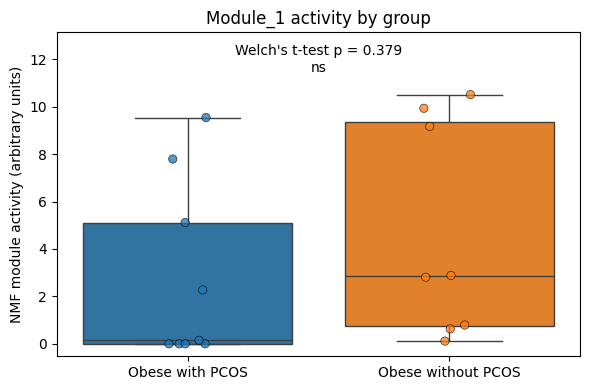

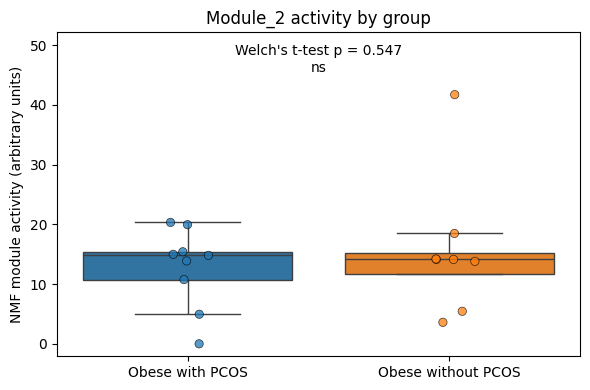

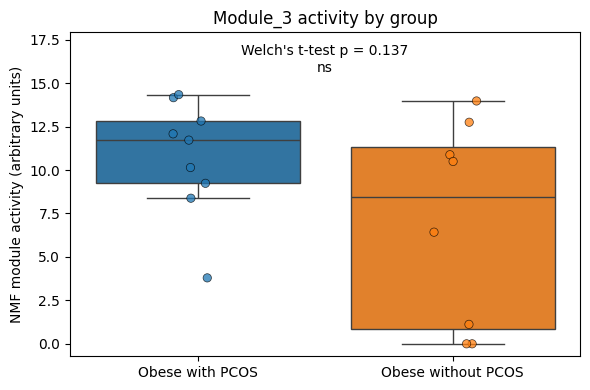

,Module,PCOS_mean,Control_mean,p_value
0,Module_1,2.762968,4.604153,0.378897
1,Module_2,12.778371,15.681720,0.546979
2,Module_3,10.741654,6.954743,0.136625


In [36]:
#Boxplots for module activity by group

label_map = {
    "PCOS": "Obese with PCOS",
    "Control": "Obese without PCOS"
}

module_activity["group_label"] = module_activity["group"].map(label_map)

order = ["Obese with PCOS", "Obese without PCOS"]

# palette keys must match group_label values
boxplot_palette = {
    "Obese with PCOS": "#1f77b4",        # blue
    "Obese without PCOS": "#ff7f0e"      # orange
}

module_stats = []

for module in [c for c in module_activity.columns if c.startswith("Module_")]:

    pcos_vals = module_activity.loc[module_activity["group"] == "PCOS", module].dropna()
    ctrl_vals = module_activity.loc[module_activity["group"] == "Control", module].dropna()

    stat, pval = ttest_ind(pcos_vals, ctrl_vals, equal_var=False)

    module_stats.append({
        "Module": module,
        "PCOS_mean": pcos_vals.mean(),
        "Control_mean": ctrl_vals.mean(),
        "p_value": pval
    })

    plt.figure(figsize=(6, 4))

    sns.boxplot(
        data=module_activity,
        x="group_label",
        y=module,
        hue="group_label",
        order=order,
        palette=boxplot_palette,
        showfliers=False,
        legend=False
    )

    sns.stripplot(
        data=module_activity,
        x="group_label",
        y=module,
        hue="group_label",
        order=order,
        palette=boxplot_palette,
        dodge=False,
        alpha=0.75,
        size=6,
        jitter=True,
        edgecolor="black",
        linewidth=0.5,
        legend=False
    )

    y_max = module_activity[module].max()
    y_min = module_activity[module].min()
    y_range = y_max - y_min if y_max != y_min else 1

    plt.text(
        0.5,
        y_max + 0.08 * y_range,
        f"Welch's t-test p = {pval:.3f}\nns",
        ha="center",
        va="bottom",
        fontsize=10
    )

    plt.ylim(y_min - 0.05 * y_range, y_max + 0.25 * y_range)

    plt.title(f"{module} activity by group")
    plt.xlabel("")
    plt.ylabel("NMF module activity (arbitrary units)")

    plt.tight_layout()
    plt.savefig(
        os.path.join(PLOTDIR, f"{module}_activity_boxplot_pvalue.png"),
        dpi=300
    )
    plt.show()

module_stats_df = pd.DataFrame(module_stats)
module_stats_df.to_csv(os.path.join(OUTDIR, "nmf_module_stats.csv"), index=False)

display(module_stats_df)